### Lab 04: RANDOM FOREST CLASSIFIER

### **Student Information**

- **Name:** Abdullah Farooq
- **Roll_no:** 24F-AI-050

#### Lab Tasks:

- Load a dataset for classification (e.g., Titanic, Breast Cancer dataset).
- Apply data preprocessing (handle missing values, encode categorical data).
- Split the dataset into training and testing sets.
- Train a Random Forest Classifier on the training data.
- Make predictions on the test set.
- Evaluate performance using accuracy, precision, recall, and F1-score.
- Visualize the Confusion Matrix
- Compare with a Single Decision Tree

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score, 
    confusion_matrix, 
    classification_report
)

# Set standard plotting style
sns.set_theme(style="whitegrid")

In [2]:
plt.rcParams['figure.figsize'] = [4.4, 3.1]

plt.rcParams['figure.autolayout'] = True

In [3]:
# Task 1: Load Dataset

# Loading Titanic dataset from Seaborn
df = sns.load_dataset('titanic')
display(df.head())

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [4]:
# Task 2: Data Preprocessing

# Handle missing values
df['age'] = df['age'].fillna(df['age'].median())
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

# Select feature subset and target variable
features = ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']
X = df[features].copy()
y = df['survived'].copy()

# Encode categorical data using one-hot encoding
X = pd.get_dummies(X, columns=['sex', 'embarked'], drop_first=True)

print("\nPreprocessed Features:")
display(X.head())


Preprocessed Features:


,pclass,age,sibsp,parch,fare,sex_male,embarked_Q,embarked_S
0,3,22.0,1,0,7.2500,True,False,True
1,1,38.0,1,0,71.2833,False,False,False
2,3,26.0,0,0,7.9250,False,False,True
3,1,35.0,1,0,53.1000,False,False,True
4,3,35.0,0,0,8.0500,True,False,True


In [5]:
# Task 3: Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

In [6]:
# Task 4 & 5: Train Random Forest & Make Predictions

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

In [7]:
# Task 6: Evaluate Performance

acc_rf = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf)
rec_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print("\n--- Random Forest Performance Metrics ---")
print(f"Accuracy:  {acc_rf:.4f}")
print(f"Precision: {prec_rf:.4f}")
print(f"Recall:    {rec_rf:.4f}")
print(f"F1-Score:  {f1_rf:.4f}\n")

print("Classification Report:\n")
print(classification_report(y_test, y_pred_rf, target_names=['Did Not Survive', 'Survived']))


--- Random Forest Performance Metrics ---
Accuracy:  0.8212
Precision: 0.8000
Recall:    0.7568
F1-Score:  0.7778

Classification Report:

                 precision    recall  f1-score   support

Did Not Survive       0.83      0.87      0.85       105
       Survived       0.80      0.76      0.78        74

       accuracy                           0.82       179
      macro avg       0.82      0.81      0.81       179
   weighted avg       0.82      0.82      0.82       179



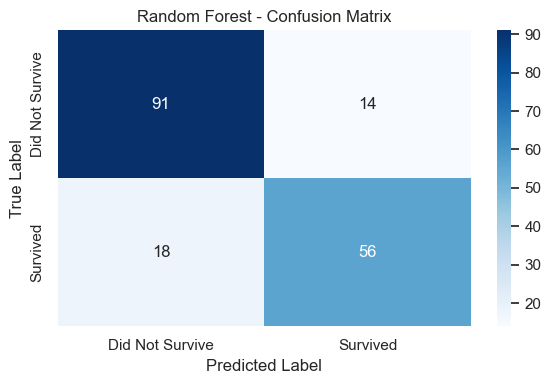

In [8]:
# Task 7: Visualize Confusion Matrix

cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm_rf, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    xticklabels=['Did Not Survive', 'Survived'], 
    yticklabels=['Did Not Survive', 'Survived']
)
plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [9]:
# Task 8: Compare with a Single Decision Tree

# Train a single Decision Tree Classifier
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

# Calculate Decision Tree metrics
acc_dt = accuracy_score(y_test, y_pred_dt)
prec_dt = precision_score(y_test, y_pred_dt)
rec_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)

# Performance Comparison Table
comparison_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Single Decision Tree': [acc_dt, prec_dt, rec_dt, f1_dt],
    'Random Forest': [acc_rf, prec_rf, rec_rf, f1_rf]
})

print("--- Performance Comparison ---")
display(comparison_df)

--- Performance Comparison ---


,Metric,Single Decision Tree,Random Forest
0,Accuracy,0.782123,0.821229
1,Precision,0.727273,0.800000
2,Recall,0.756757,0.756757
3,F1-Score,0.741722,0.777778
